# Nominal MPC Generation
Uses an MPC controller to generate nominal control inputs for each episode. Note that this assumes there are no CBFs generated by any required keep-out regions.

In [1]:
import pathlib
import itertools
import h5py
import numpy as np

from dataclasses import dataclass
from scipy.integrate import solve_ivp

from typing import Callable

from mpc_controller import (
    Trajectory,
    DynExtUnicycleMCPParams,
    dyn_ext_unicycle_model_step,
    dyn_ext_unicycle_cost,
    gen_mpc_controls,
)

import matplotlib.pyplot as plt

from multiprocessing import Pool
import tqdm

In [2]:
episodes_train_dir = pathlib.Path("../data/episodes/train")
episodes_test_dir = pathlib.Path("../data/episodes/test")

In [3]:
# load all the episodes from file into memory (so we can parallelize nominal
# control input generation for performance)


def load_from_h5(h5_file_dir):
    episodes = []
    files = []
    for file in h5_file_dir.iterdir():
        if file.name == ".gitkeep":
            continue  # don't try to load this one
        episode = dict()
        with h5py.File(file, "r") as f:
            f.visititems(lambda name, obj: episode.update({name: np.asarray(obj)}))
            episode.update(f.attrs)
        episodes.append(episode)
        files.append(file.name)
    return episodes, files


train_episodes, train_files = load_from_h5(episodes_train_dir)
test_episodes, test_files = load_from_h5(episodes_test_dir)

train_episodes[0]

{'ddx_traj': array([ 0.02141311,  0.02131748,  0.02122186,  0.02112623,  0.0210306 ,
         0.02093497,  0.02083934,  0.02074371,  0.02064808,  0.02055246,
         0.02045683,  0.0203612 ,  0.02026557,  0.02016994,  0.02007431,
         0.01997869,  0.01988306,  0.01978743,  0.0196918 ,  0.01959617,
         0.01950054,  0.01940491,  0.01930929,  0.01921366,  0.01911803,
         0.0190224 ,  0.01892677,  0.01883114,  0.01873552,  0.01863989,
         0.01854426,  0.01844863,  0.018353  ,  0.01825737,  0.01816174,
         0.01806612,  0.01797049,  0.01787486,  0.01777923,  0.0176836 ,
         0.01758797,  0.01749235,  0.01739672,  0.01730109,  0.01720546,
         0.01710983,  0.0170142 ,  0.01691857,  0.01682295,  0.01672732,
         0.01663169,  0.01653606,  0.01644043,  0.0163448 ,  0.01624918,
         0.01615355,  0.01605792,  0.01596229,  0.01586666,  0.01577103,
         0.0156754 ,  0.01557978,  0.01548415,  0.01538852,  0.01529289,
         0.01519726,  0.01510163,  0.01

In [4]:
dist_cost = 5.0
ang_cost = 2.0

u_cost = 2.75*np.diag([1.0, 1.2])

k_base = 2.0
future_pred_cost_factor = lambda k: k_base**k if k > 0 else 1.0

num_mpc_steps = 5
mpc_dt = 0.5

In [5]:
def gen_controls_for_episode(
    episode,
    dist_cost,
    ang_cost,
    u_cost,
    future_pred_cost_factor,
    num_mpc_steps,
):
    # generates the state and control history for the episode

    p_hist = []  # state history
    u_hist = []  # control history

    traj_err_hist = []  # position tracking error

    # really only care about the randomized position as given the distribution
    # it will have angles distributed with respect to the ideal trajectory
    # anyways so this should be fine
    # NOTE: also start at zero velocity or angular velocity
    p_curr = np.array([*episode["start_pos"], 0.0, 0.0, 0.0])
    u_curr = np.zeros(2)

    # print(f"Start pos: {p_curr}")

    dt = episode["sample_time"]

    # setup the trajectory and parameters
    t = episode["t_traj"]

    traj = Trajectory(
        dt,
        t,
        episode["x_traj"],
        episode["y_traj"],
        episode["dx_traj"],
        episode["dy_traj"],
        episode["ddx_traj"],
        episode["ddy_traj"],
    )

    params = DynExtUnicycleMCPParams(
        dist_cost, ang_cost, u_cost, future_pred_cost_factor, traj
    )

    for i in range(len(t)):
        t_curr = t[i]

        # print(f"t_curr: {t_curr}")

        u_optimal, _ = gen_mpc_controls(
            t_curr,
            p_curr,
            num_mpc_steps,
            mpc_dt,
            u_curr,
            params,
            dyn_ext_unicycle_model_step,
            dyn_ext_unicycle_cost,
        )

        p_hist.append(p_curr)
        u_hist.append(u_optimal)

        # NOTE: technically this trajectory error can be computed afterwards but
        # for convenience it will be computed here and is immediately available
        x_traj_curr, y_traj_curr, _, _, _, _ = traj(t_curr)
        traj_err = np.array([x_traj_curr - p_curr[0], y_traj_curr - p_curr[1]])
        traj_err_hist.append(traj_err)

        # updates the current position afterwards so it considers the initial
        # condition when generating the frist control input
        p_curr = dyn_ext_unicycle_model_step(t_curr, dt, p_curr, u_optimal, params)

        # for testing
        # if i > 3000:
        #     break

    return np.array(p_hist), np.array(u_hist), np.array(traj_err_hist)

In [6]:
test_episode = train_episodes[0]
p_hist, u_hist, traj_err_hist = gen_controls_for_episode(
    test_episode,
    dist_cost,
    ang_cost,
    u_cost,
    future_pred_cost_factor,
    num_mpc_steps,
)

In [7]:
p_hist.shape
u_hist

array([[ 4.76386687e-02,  1.70465216e+00],
       [ 9.99182403e-02,  1.48996372e+00],
       [ 1.50150646e-01,  1.29093302e+00],
       [ 1.97056872e-01,  1.10651212e+00],
       [ 2.39626771e-01,  9.35745231e-01],
       [ 2.77095025e-01,  7.77769205e-01],
       [ 3.08925693e-01,  6.31812085e-01],
       [ 3.34776066e-01,  4.97182372e-01],
       [ 3.54491840e-01,  3.73264935e-01],
       [ 3.68074560e-01,  2.59509635e-01],
       [ 3.75661645e-01,  1.55423113e-01],
       [ 3.77499024e-01,  6.05599399e-02],
       [ 3.73927916e-01, -2.54837863e-02],
       [ 3.65354966e-01, -1.03076409e-01],
       [ 3.52240188e-01, -1.72560202e-01],
       [ 3.35082716e-01, -2.34250973e-01],
       [ 3.14405743e-01, -2.88447191e-01],
       [ 2.90749708e-01, -3.35433484e-01],
       [ 2.64664609e-01, -3.75487388e-01],
       [ 2.36702541e-01, -4.08887251e-01],
       [ 2.07415074e-01, -4.35914688e-01],
       [ 1.77342262e-01, -4.56866393e-01],
       [ 1.47009301e-01, -4.72056602e-01],
       [ 1.

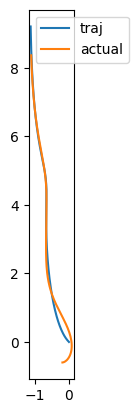

In [8]:
# fairly decent adherence to the trajectory and if anymore aggressive then the
# commanded inputs will be higher than what we'd expect for a comparative robot

fig, ax = plt.subplots(1, 1)

ax.plot(test_episode["x_traj"], test_episode["y_traj"], label="traj")
ax.plot(p_hist[:, 0], p_hist[:, 1], label="actual")

ax.set_aspect("equal")
ax.legend()

plt.show()

In [9]:
def gen_controls_for_episode_wrapped(episode):
    # unable to use a lambda function so this just feeds in the parameter
    # values and can be used with multiprocessing

    return gen_controls_for_episode(
        episode,
        dist_cost,
        ang_cost,
        u_cost,
        future_pred_cost_factor,
        num_mpc_steps,
    )


# sets up a subset of the data to evaluate (if necessary)
train_episodes_subset = train_episodes[:]
test_episodes_subset = test_episodes[:]

with Pool(processes=28) as pool:
    print("Beginning computation of mpc controller for train episodes...")
    train_episodes_results = list(
        tqdm.tqdm(
            pool.imap(gen_controls_for_episode_wrapped, train_episodes_subset),
            total=len(train_episodes_subset),
        )
    )
    print("Beginning computation of mpc controller for test episodes...")
    test_episodes_results = list(
        tqdm.tqdm(
            pool.imap(gen_controls_for_episode_wrapped, test_episodes_subset),
            total=len(test_episodes_subset),
        )
    )

Beginning computation of mpc controller for train episodes...


100%|██████████| 6/6 [00:26<00:00,  4.33s/it]


Beginning computation of mpc controller for test episodes...


100%|██████████| 3/3 [00:23<00:00,  7.92s/it]


In [10]:
episodes_train_dir = pathlib.Path("../data/nominal_mpc/train")
episodes_test_dir = pathlib.Path("../data/nominal_mpc/test")

# empty these repositories so we have no issues when writing the episodes that
# were generated in the preceding section
for file in itertools.chain(episodes_train_dir.iterdir(), episodes_test_dir.iterdir()):
    if file.name == ".gitkeep":
        continue  # don't delete this file
    file.unlink()

# writes all the training data
num_train_results = len(train_episodes_results)
num_test_results = len(test_episodes_results)

for i in range(num_train_results + num_test_results):
    p_hist, u_hist, traj_err_hist = (
        train_episodes_results[i]
        if i < num_train_results
        else test_episodes_results[i - num_train_results]
    )

    file = (
        episodes_train_dir.joinpath(train_files[i])
        if i < num_train_results
        else episodes_test_dir.joinpath(test_files[i - num_train_results])
    )
    with h5py.File(file, "w") as f:
        f.create_dataset("p_hist", data=p_hist)
        f.create_dataset("u_hist", data=u_hist)
        f.create_dataset("traj_err_hist", data=traj_err_hist)

        # write the parameters used for the mpc controller
        f.attrs["dist_cost"] = dist_cost
        f.attrs["ang_cost"] = ang_cost
        f.attrs["u_cost"] = u_cost
        f.attrs["k_base"] = k_base
        f.attrs["num_mpc_steps"] = num_mpc_steps
        f.attrs["mpc_dt"] = mpc_dt

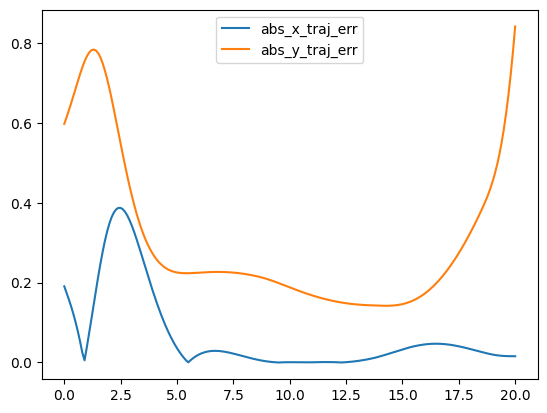

In [11]:
err = train_episodes_results[0][2]  # trajectory error

fig, ax = plt.subplots(1, 1)

ax.plot(train_episodes_subset[0]["t_traj"], abs(err[:, 0]), label="abs_x_traj_err")
ax.plot(train_episodes_subset[0]["t_traj"], np.abs(err[:, 1]), label="abs_y_traj_err")

ax.legend()

plt.show()